In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
df = df[df.metric == metric]
df = df[~df.subj_id.isin(controls)]

region = ['ICP']
regions = [f'{region[0]}_R', f'{region[0]}_L']
df = df[df.Object.isin(regions)]

/localscratch/tmp/ipykernel_43423/448266703.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


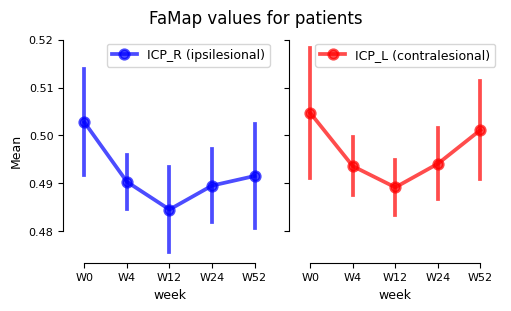

In [2]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, constrained_layout = True)
sns.pointplot(x = 'week', y = 'Mean', data = df[df.Object == regions[0]], alpha = .7, label = f'{regions[0]} (ipsilesional)', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Mean', data = df[df.Object == regions[1]], alpha = .7, label = f'{regions[1]} (contralesional)', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'{metric} values for patients')
plt.legend()
sns.despine(trim = True)
plt.show()

In [48]:
print(f'---t-test between affected and unaffected CST patients--- \n')

for week in df.week.unique():
    t_val, p_val = stats.ttest_rel(df[(df.week == week) & (df.Object == f'{region[0]}_R')]['Mean'], df[(df.week == week) & (df.Object == f'{region[0]}_L')]['Mean'], alternative = 'greater')
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between affected and unaffected CST patients--- 

Week W0: t-value = 0.5499582258691211, p-value = 0.29720871485105804 

Week W4: t-value = 0.400187492645901, p-value = 0.34715537693894943 

Week W12: t-value = 3.1727506709628894, p-value = 0.003389021083048515 

Week W24: t-value = 1.4708604470549, p-value = 0.0817229080960814 

Week W52: t-value = 2.2825773850785707, p-value = 0.02279275608409104 



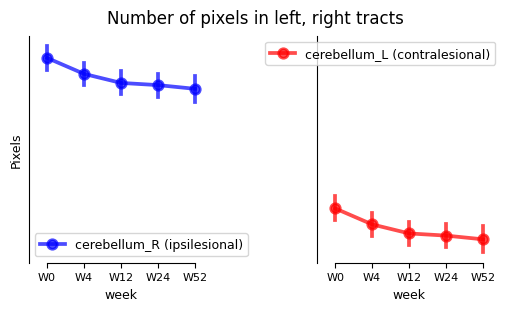

In [46]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, constrained_layout = True)
sns.pointplot(x = 'week', y = 'Pixels', data = df[df.Object == regions[0]], alpha = .7, label = f'{regions[0]} (ipsilesional)', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Pixels', data = df[df.Object == regions[1]], alpha = .7, label = f'{regions[1]} (contralesional)', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'Number of pixels in left, right tracts')
plt.legend()
axs[0].set_yticklabels([])
axs[0].set_yticks([])
sns.despine(trim = True)
plt.show()